# Variational Inference: Spam Detection

In this assignment, we will load the UCI SMS Spam Collection dataset.
However, instead of using it directly, we will use fixed-size vector embeddings of the message.
Those embeddings have already been produced and are provided here to you.


## Setting the Scene

The goal of this assignment to go beyond a traditional classifier and apply variational methods.
This means that we will train a model using some parameters over the distribution of which we have a prior belief.
Our prior belief here is actually that each and every parameter independently follows a standard normal distribution.


During optimization, we will draw sets of parameters from our variational distribution $q_{\phi}$.
Drawing these parameters needs to be done using the reparameterization trick, so that we can add noise, i.e., $w_i=\mu_i+\sigma_i\cdot\epsilon$.
The assignment also poses one or the other question (clearly marked), you need to provide your answer directly after.


The assignment has some blank spots for you to fill out (but you can customize your implementation to your liking).
Training should be done using stochastic gradient descend, either using manual gradient updates or using an optimizer.

You should use autodiff-capabilities to compute gradients.
It is recommended to use, for example, JAX or PyTorch.
We recommend the latter, using it in a functional way (i.e., using `torch.func.jacrev`).
The blanks left in this assignment and their type hints assume PyTorch.
There are some cells with quick tests/sanity-checks, that you are free to remove, especially if they do not go along with how you chose to implement your solution.


At the end of the assignment, after training, you need to pick one advanced method of evaluation.
We are not interested in traditional metrics here (e.g., accuracy, Kappa, F1, etc.; although you are welcome to show those).
Rather, we want to exploit the variational nature of the model here and show something more interesting.

# Load the Data

You're variational model shall use no more than 15 components (aim for ~5 or fewer).
You'll have to apply a dimensionality reduction.

Sentence Embeddings were created in two ways:

1. (Recommended) Using [ALBERT XLarge v2](https://huggingface.co/albert/albert-xlarge-v2) (`albert-xlarge-v2`). Dim $=2,048$.
2. Using [English word vectors](https://fasttext.cc/docs/en/english-vectors.html) from `wiki-news-300d-1M` using `fasttext`. Dim $=300$.

In either case, the embeddings were averaged along the sequence dimension to produce fixed-size vectors.
In the provided dataset, the messages are retained.
This is useful should you choose a qualitative evaluation.

The labels have already been converted to floats: 0.0=ham, 1.0=spam.
The default example below shows a spam message.

In [69]:
# Modify only the file you wish to load.
# Each data file contains 3 keys: X, y, msg
import numpy as np

data = np.load(file='data/2048d_sms_spam_albert-xlarge-v2.npz')
# data = np.load(file='data/300d_sms_spam_fasttext_pca.npz')

X: np.ndarray; Y: np.ndarray
X, Y, msg = data.get('X'), data.get('y'), data.get('msg')
X.shape, Y.shape, len(msg), msg[2], Y[2]

((5572, 2048),
 (5572,),
 5572,
 np.str_("Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's"),
 np.int64(1))

# Define the Model

Our model is to be a polynomial with degree corresponding to the number of components chosen for the PCA.

$$
\begin{align}
    z=w_0+w_1\cdot x_1+w_2x_2^2+\dots+w_nx_n^n.
\end{align}
$$

We will perform a **binary** classification problem, using the binary cross-entropy (CE).
CE has a range of $[0,\infty)$.
The better the predictions of our model, the lower the CE.


Note that binary CE requires our predictions to be in the range $[0,1]$.
Therefore, we will have to pass its raw outputs ("logits") through the Sigmoid function.
This makes our model a **logistic** classifier.
The Sigmoid function is defined as $s(x)=\frac{1}{1+e^{-z}}$.

$$
\begin{align}
    p_i&=s(z_i),\;\text{convert our raw predictions to probabilities, then:}
    \\[1ex]
    \hat{y}_i&\sim\text{Bernoulli}(p_i).
\end{align}
$$


Since our predicted $\hat{y}$ will follow a Bernoulli distribution, we can directy use its likelihood function.
Note that maximizing the Bernoulli likelihood is equivalent of minimizing the binary CE!
The Bernoulli distribution is parameterized by a single parameter, **$p$**.


However, in our context, $p$ is unknown.
In order not to confuse the Bernoulli distribution's parameter $p$ with anything, in the following, we have substituted it with $s(z_i)$.
We will optimize for it, so that the output of our logisitic classifier becomes $p$.
The likelihood (for the prediction $\hat{y}_i$ of a single observation and its label $y_i$) then becomes:

$$
\begin{align}
    p(\mathbf{y}|\mathbf{X},\mathbf{w})&=\prod_i\,s(z_i)^{y_i}\cdot(1-s(z_i))^{1-y_i},
    \\
    \log{(p(\mathbf{y}|\mathbf{X},\mathbf{w}))}&=\sum_i\,\left[\log{(s(z_i)^{y_i})}+\log{((1-s(z_i))^{1-y_i})}\right],
    \\
    &=\sum_i\,\left[y_i\cdot\log{(s(z_i))} + (1-y_i)\cdot\log{(1-s(z_i))}\right].
\end{align}
$$

* Our **prior** belief is that each parameter follows a standard normal distribution, i.e., $w_j\sim\mathcal{N}(0,1)$.
* For our variational distribution, use a mean-field approximation of standard (independent) normals, too.


**Question**: Conceptually, how does the log-likelihood $p(y|x,w)$ compute its result given a single $n$-dimensional observation under the assumption of independent dimensions?

**Answer**: For a single observation, the model first combines the input dimensions into one scalar logit using the polynomial expression, then maps this logit through the sigmoid function to obtain a Bernoulli probability. For multiple independent observations, the likelihood is the product of the individual Bernoulli likelihoods, and the log-likelihood is therefore the sum of the individual log-likelihoods.

# Implement the Model

Here, you are encouraged to use a library/framework like PyTorch or JAX and esp. functionality for automatic differentiation to compute gradients.
You may also import functions like `sigmoid` or `vmap` for vectorized operations.

It is recommended to implement vectorized versions of your required functions (i.e., batch-processing).

It is preferable to use type-hints for your functions.
Furthermore, you can write better code by inserting assertions (e.g., for dimensionality or other sanity-checks).
Please use Python-style comments like in the following:

```python
def func(w0: float, x: float) -> float:
    """
    Function to compute a multiple of x.
    """
    ...
```

In [70]:
import torch
from torch import Tensor


def model(w: Tensor, x: Tensor) -> Tensor:
    """
    Takes the coefficients w, the observations, computes the polynomial and
    returns probabilities.
    
    w shape:
        (num_params,) or (S, num_params)

    x shape:
        (N, num_features)

    returns:
        If S > 1: shape (S, N)
        If S == 1: shape (N,)
    """
    if x.ndim == 1:
        x = x.unsqueeze(0)

    if w.ndim == 1:
        w = w.unsqueeze(0)

    assert x.ndim == 2
    assert w.ndim == 2
    assert w.shape[1] == x.shape[1] + 1

    powers = torch.arange(
        start=1,
        end=x.shape[1] + 1,
        dtype=x.dtype,
        device=x.device,
    )

    x_poly = x ** powers

    intercept = w[:, 0].unsqueeze(1)
    weights = w[:, 1:]

    logits = intercept + weights @ x_poly.T
    probs = torch.sigmoid(logits)

    if probs.shape[0] == 1:
        return probs.squeeze(0)

    return probs

In [71]:
# Sanity-check, we should get 4 outputs if the model is correctly vectorized!
temp = model(w=torch.rand(size=(1,6)), x=torch.rand(size=(4,5)))
temp

tensor([0.8030, 0.7219, 0.7244, 0.6707])

## The Likelihood function

In [72]:
def log_lik(y_true: Tensor, y_hat: Tensor) -> Tensor:
    """
    For one or more observations, where y_true is the true label (0 or 1)
    and y_hat contains predicted probabilities [0,1], computes the (log)
    likelihood.
    """
    eps = 1e-7

    y_true = y_true.float().reshape(-1)
    y_hat = torch.clamp(y_hat.float(), min=eps, max=1 - eps)

    if y_hat.ndim == 1:
        return (
            y_true * torch.log(y_hat)
            + (1 - y_true) * torch.log(1 - y_hat)
        ).sum()

    return (
        y_true.unsqueeze(0) * torch.log(y_hat)
        + (1 - y_true.unsqueeze(0)) * torch.log(1 - y_hat)
    ).sum(dim=1)

In [73]:
# Sanity-check, should be a single element here:
log_lik(y_true=torch.tensor(data=[1,0,1,0], dtype=torch.float), y_hat=temp)

tensor(-2.9326)

# The Evidence Lower BOund (ELBO)

Optimizing the ELBO (maximization) is the same as minimizing the KL divergence.
Here, the students shall implement a **Monte Carlo** approximation.

According to the slides, this is how it's done:

1. Sample from approximate posterior distribution $q_{\phi}(\theta)$.
    * Direct sampling methods should be used (we have a well-defined mean-field approximation here).
    * Apply reparameterization trick to train the model. Note: Do **not** use amortized variational inference here.
2. Estimate the ELBO using stochastic gradient-based optimization.

---------

Remember that the Bayesian framework tells us something about the *model*.
The variational approach allows us to **empirically** estimate the overall goodness of fit of our model.

In order to do that sufficiently well, we need more than just point estimates.
Recall that we do **not** attempt to find some best point estimates for our data, but rather a distribution over them.
In order for that to work well, we need to test many different parameter constellations and average over those results.
In other words, we need to draw many different sets of possible variational distribution parameters and check how well these allow our model, on average, to predict the constant observations.


-------

Recall the definition of the ELBO:

$$
\begin{align}
    \text{ELBO}&=\mathbb{E}_{q_{\phi}(\mathbf{w})}\left[\log{(p(\mathbf{y}|\mathbf{X},\mathbf{w}))}\right]-D_{\text{KL}}\left(q_{\phi}(\mathbf{w})\|p(\mathbf{w})\right).
\end{align}
$$

-------

For simplicity here, assume there will be the following "loops":

1. Outermost loop is governed by the epoch ($E$).
2. The next loop is over the stochastic mini-batches of observations (batches of size $N$).
    * For each batch, you draw $w^{(s)}\in 1\dots S$ **new** different sets of parameter configurations from your variational distribution.
    * Here, you'll be using the reparameterization trick.
3. Loop over $S$:
    * (a) For each configuration $s_i$, you will have to multiply (sum) the (log) likelihood of each observation under the current likelihood function (as parameterized by $w^{(s)}$).
    * (b) Next, calculate the KL-divergence between our approximate posterior (the mean-field approximation of independent Gaussians) and our prior (which is a diagonal standard normal distribution). **Attention**:
        * You use either, the **analytical** or the **Monte Carlo** approximation of the KL-divergence. However, the analytical one is essentially *outside the expectation* (because it does not average over $w^{(s)}$), whereas the MC-approximation should perhaps be an addend/subtrahend to (a).
        * In effect, the analytical KL-divergence is calculated only **once** per batch, using the **current** variational parameters (i.e., as they were after the last optimizer's step or after initialization for first step).
    * Calculate (a) - (b), according to previous remark.
4. Average the results from step 3 (considering the remark about analytical/MC version of the KL-divergence). It needs to be an average because the ELBO is an expectation (a weighted mean) over all possible realizations of $s_i\in S$. For each individual batch, you have now an average idea of:
    * The *expected* data likelihood.
    * How strongly your prior and approximate posterior diverge from one another.
5. Do not accumulate results across batches at this point.
    * It is better to compute a gradient for each batch and apply parameter updates. Frequent, incremental updates work better in practice.


**Notes**:
* As $S$ approaches $\infty$, the MC-approximation of the KL-divergence will be equal to the analytical solution.
* For the MC-approximation, a good $S$ is perhaps $50-500$.

# Putting it all together

Let's implement the "loops" from above.
We will create stochastic mini-batches of our data to compute gradients on.
For now, we will not implement a loop for epochs.

The ELBO for a list of parameters sets $S$ and a mini-batch of length $N$ is defined as follows:

$$
\begin{align}
    \text{ELBO}(\phi)&\approx\left(\frac{1}{S}\sum_{s=1}^{S}\,\underbrace{\left[\sum_{i=1}^{N}\,\log{(p(y_i|x_i,w^{(s)}))}\right]}_{\text{log-sum of i.i.d. observations}}\right)-\underbrace{D_{\text{KL}}(q_{\mu,\sigma}(w)\|p(w))}_{\text{using the current $\mu,\sigma$}}.
    \\[4em]
    \text{Also note that}&\text{ we can use Monte Carlo to approximate the KL-divergence:}\nonumber
    \\[1em]
    D_{\text{KL}}(q_{\mu,\sigma}(w)\|p(w))&=\mathbb{E}_{w\sim q_{\mu,\sigma}(w)}\left[\log{\left(\frac{q_{\mu,\sigma}(w)}{p(w)}\right)}\right],
    \\[1em]
    &=\frac{1}{S}\sum_{s=1}^{S}\,\left[\log{\left(q_{\mu,\sigma}\left(w^{(s)}\right)\right)}-\log{\left(p\left(w^{(s)}\right)\right)}\right].
    \\[2em]
    \text{Also note that}&\text{ the KL-divergence between two normals has an analytical solution:}\nonumber
    \\[1em]
    D_{\text{KL}}(q_{\mu,\sigma}(w)\|\mathcal{N}(0,I))&=\frac{1}{2}\sum_{j=0}\,\left(\mu_j^2+\sigma_j^2-1-\log{\left(\sigma_j^2\right)}\right).
    \\[2em]
    \text{Also note that}&\text{ the ELBO including the MC-approximation of the KL-divergence is:}\nonumber
    \\[1em]
    \text{ELBO}(\phi)&\approx\frac{1}{S}\sum_{s=1}^{S}\,\underbrace{\left[\sum_{i=1}^{N}\,\log{(p(y_i|x_i,w^{(s)}))}\right]}_{\text{log-sum of i.i.d. observations}}-\underbrace{\left[\log{\left(q_{\mu,\sigma}\left(w^{(s)}\right)\right)}-\log{\left(p\left(w^{(s)}\right)\right)}\right]}_{\text{MC-approx. of KL-divergence}}.
\end{align}
$$

# Implementation

Here, implement everything you need.

## Data Preparation and Dimensionality Reduction

Start by reducing the dimensionality of your data.
Choose a combination of dataset and polynomial degree that is not too low and not too high.
Aim for at least 30% explained variance and at most 15 components.

Report the (sum of the) explained variance before you proceed.


Remember the basics: splitting, randomness, scaling, etc.

In [74]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

POLY_DEGREE = 4
RANDOM_STATE = 42
TEST_SIZE = 0.2

X_train_raw, X_test_raw, Y_train_raw, Y_test_raw, msg_train, msg_test = train_test_split(
    X,
    Y,
    msg,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=Y,
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

pca = PCA(n_components=POLY_DEGREE, random_state=RANDOM_STATE)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

explained_variance = pca.explained_variance_ratio_.sum()

print(f"Explained total variance by {POLY_DEGREE} dimensions: {explained_variance:.6f}")

X_train_t = torch.tensor(X_train_pca, dtype=torch.float32)
Y_train_t = torch.tensor(Y_train_raw, dtype=torch.float32)

X_test_t = torch.tensor(X_test_pca, dtype=torch.float32)
Y_test_t = torch.tensor(Y_test_raw, dtype=torch.float32)

X_train_t.shape, Y_train_t.shape, X_test_t.shape, Y_test_t.shape

Explained total variance by 4 dimensions: 0.375849


(torch.Size([4457, 4]),
 torch.Size([4457]),
 torch.Size([1115, 4]),
 torch.Size([1115]))

## Model

Below you'll find some prototypes (fill in the blanks).
Again, this is just a suggestion, you can come up with your own implementation.

In [75]:
def ELBO_expected_data_likelihood(y_true: Tensor, x: Tensor, W: Tensor) -> Tensor:
    """A function to calculate the first term of the ELBO."""
    y_hat = model(w=W, x=x)
    return log_lik(y_true=y_true, y_hat=y_hat).mean()


def ELBO_KL_divergence_analytical(mu: Tensor, sigma: Tensor) -> Tensor:
    """The analytical version of the KL divergence."""
    sigma = torch.clamp(sigma, min=1e-7)

    return 0.5 * torch.sum(
        mu**2 + sigma**2 - 1 - torch.log(sigma**2)
    )


def ELBO_KL_divergence_Monte_Carlo(W: Tensor, mu: Tensor, sigma: Tensor) -> Tensor:
    """
    The Monte Carlo approximation of the KL divergence.
    You don't need to implement both, one is enough.
    """
    sigma = torch.clamp(sigma, min=1e-7)

    log_2pi = torch.log(torch.tensor(2.0 * torch.pi, dtype=W.dtype, device=W.device))

    log_q = -0.5 * (
        ((W - mu) / sigma) ** 2
        + 2 * torch.log(sigma)
        + log_2pi
    ).sum(dim=1)

    log_p = -0.5 * (
        W**2 + log_2pi
    ).sum(dim=1)

    return (log_q - log_p).mean()

In [76]:
from typing import Literal

NUM_VARIATIONAL_SETS = 50
KL_DIV_TYPE = Literal['analytical', 'montecarlo']


def ELBO(use_mu: Tensor, use_sigma: Tensor, y_true: Tensor, obs: Tensor, variational_params_noise: Tensor, kl: KL_DIV_TYPE='analytical', return_exp_data_lik: bool=False, return_kl_div: bool=False) -> Tensor|tuple[Tensor, ...]:
    """
    Convenience function that uses the current variational parameters,
    applies the reparameterization trick, and computes the complete
    ELBO. The result of this function shall be maximized.
    """
    use_sigma = torch.clamp(use_sigma, min=1e-7)

    W = use_mu.unsqueeze(0) + use_sigma.unsqueeze(0) * variational_params_noise

    exp_data_lik = ELBO_expected_data_likelihood(
        y_true=y_true,
        x=obs,
        W=W,
    )

    if kl == "analytical":
        kl_div = ELBO_KL_divergence_analytical(
            mu=use_mu,
            sigma=use_sigma,
        )
    elif kl == "montecarlo":
        kl_div = ELBO_KL_divergence_Monte_Carlo(
            W=W,
            mu=use_mu,
            sigma=use_sigma,
        )
    else:
        raise ValueError("kl must be either 'analytical' or 'montecarlo'.")

    elbo_value = exp_data_lik - kl_div

    outputs = [elbo_value]

    if return_exp_data_lik:
        outputs.append(exp_data_lik)

    if return_kl_div:
        outputs.append(kl_div)

    if len(outputs) == 1:
        return outputs[0]

    return tuple(outputs)


ELBO_grad = torch.func.grad(
    lambda use_mu, use_sigma, y_true, obs, variational_params_noise: ELBO(
        use_mu=use_mu,
        use_sigma=use_sigma,
        y_true=y_true,
        obs=obs,
        variational_params_noise=variational_params_noise,
        kl="analytical",
    ),
    argnums=(0, 1),
)

# Training

Train your model until convergence.
Choose a number of iterations, batch-size, and learning rate that make sense in your scenario.
Do not perform a grid search or other hyperparameter optimization.
Instead, manually find some good working parameters and make your final solution just use these.


* **Plot** the training curve (i.e., plot the history for each component of the ELBO).
* **Print** the final parameters for your variational distribution after optimization.
* **Evaluate** the ELBO on the holdout dataset. Is it close? You could also do this during training.

Epoch 000 | ELBO: -722.573 | Expected log-likelihood: -709.907 | KL: 12.665
Epoch 020 | ELBO: -322.353 | Expected log-likelihood: -308.991 | KL: 13.363
Epoch 040 | ELBO: -285.088 | Expected log-likelihood: -270.893 | KL: 14.194
Epoch 060 | ELBO: -257.746 | Expected log-likelihood: -242.178 | KL: 15.569
Epoch 080 | ELBO: -233.625 | Expected log-likelihood: -216.315 | KL: 17.310
Epoch 099 | ELBO: -219.204 | Expected log-likelihood: -200.011 | KL: 19.194

Final variational means:
tensor([-2.5951e+00,  1.3950e-02,  1.6356e-02,  3.5914e-04, -8.7292e-02])

Final variational standard deviations:
tensor([0.5251, 0.0348, 0.0064, 0.0031, 0.0329])


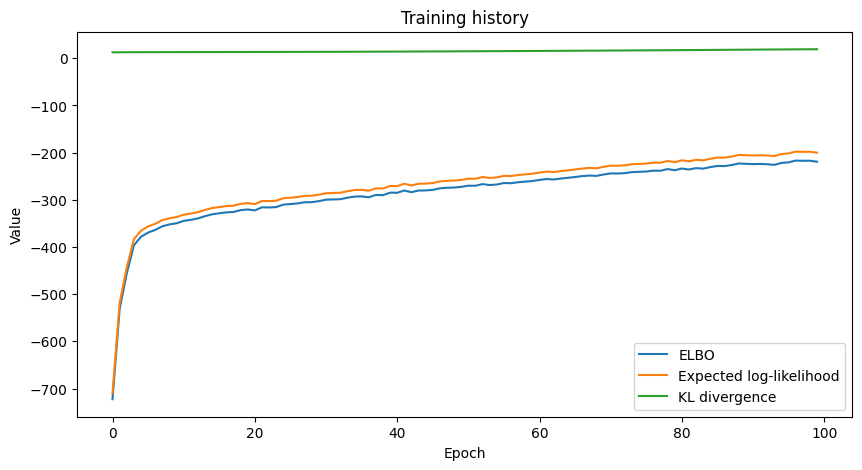


Holdout evaluation:
ELBO: -1837.583
Expected log-likelihood: -1818.330
KL divergence: 19.253

Normalized holdout evaluation:
ELBO per observation: -1.648
Expected log-likelihood per observation: -1.631
KL divergence per observation: 0.017


In [ ]:
# Training loop for variational inference using mini-batch ELBO optimization.
import matplotlib.pyplot as plt
import torch.nn.functional as F

EPOCHS = 100
LEARNING_RATE = 0.001
USE_KL_TYPE: KL_DIV_TYPE = "analytical"
BATCH_SIZE = 128

torch.manual_seed(RANDOM_STATE)

num_params = POLY_DEGREE + 1

mu = torch.zeros(num_params, dtype=torch.float32, requires_grad=True)

# We optimize rho, then transform it into sigma using softplus.
# This guarantees sigma stays positive.
rho = torch.full(
    size=(num_params,),
    fill_value=-3.0,
    dtype=torch.float32,
    requires_grad=True,
)

optimizer = torch.optim.Adam([mu, rho], lr=LEARNING_RATE)

history_elbo = []
history_exp_lik = []
history_kl = []

n_train = X_train_t.shape[0]

for epoch in range(EPOCHS):
    permutation = torch.randperm(n_train)

    epoch_elbo = []
    epoch_exp_lik = []
    epoch_kl = []

    for start_idx in range(0, n_train, BATCH_SIZE):
        batch_idx = permutation[start_idx:start_idx + BATCH_SIZE]

        x_batch = X_train_t[batch_idx]
        y_batch = Y_train_t[batch_idx]

        sigma = F.softplus(rho) + 1e-5

        noise = torch.randn(
            size=(NUM_VARIATIONAL_SETS, num_params),
            dtype=torch.float32,
        )

        elbo_value, exp_data_lik, kl_div = ELBO(
            use_mu=mu,
            use_sigma=sigma,
            y_true=y_batch,
            obs=x_batch,
            variational_params_noise=noise,
            kl=USE_KL_TYPE,
            return_exp_data_lik=True,
            return_kl_div=True,
        )

        loss = -elbo_value

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_elbo.append(elbo_value.detach().item())
        epoch_exp_lik.append(exp_data_lik.detach().item())
        epoch_kl.append(kl_div.detach().item())

    history_elbo.append(np.mean(epoch_elbo))
    history_exp_lik.append(np.mean(epoch_exp_lik))
    history_kl.append(np.mean(epoch_kl))

    if epoch % 20 == 0 or epoch == EPOCHS - 1:
        print(
            f"Epoch {epoch:03d} | "
            f"ELBO: {history_elbo[-1]:.3f} | "
            f"Expected log-likelihood: {history_exp_lik[-1]:.3f} | "
            f"KL: {history_kl[-1]:.3f}"
        )

sigma_final = F.softplus(rho).detach() + 1e-5
mu_final = mu.detach()

print("\nFinal variational means:")
print(mu_final)

print("\nFinal variational standard deviations:")
print(sigma_final)

plt.figure(figsize=(10, 5))
plt.plot(history_elbo, label="ELBO")
plt.plot(history_exp_lik, label="Expected log-likelihood")
plt.plot(history_kl, label="KL divergence")
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.title("Training history")
plt.legend()
plt.show()

with torch.no_grad():
    test_noise = torch.randn(
        size=(NUM_VARIATIONAL_SETS, num_params),
        dtype=torch.float32,
    )

    test_elbo, test_exp_lik, test_kl = ELBO(
        use_mu=mu_final,
        use_sigma=sigma_final,
        y_true=Y_test_t,
        obs=X_test_t,
        variational_params_noise=test_noise,
        kl=USE_KL_TYPE,
        return_exp_data_lik=True,
        return_kl_div=True,
    )

print("\nHoldout evaluation:")
print(f"ELBO: {test_elbo.item():.3f}")
print(f"Expected log-likelihood: {test_exp_lik.item():.3f}")
print(f"KL divergence: {test_kl.item():.3f}")


print("\nNormalized holdout evaluation:")
print(f"ELBO per observation: {test_elbo.item() / len(Y_test_t):.3f}")
print(f"Expected log-likelihood per observation: {test_exp_lik.item() / len(Y_test_t):.3f}")
print(f"KL divergence per observation: {test_kl.item() / len(Y_test_t):.3f}")

# Advanced Model Evaluation (Pick <u>One</u>)

In this last part of the assignment, you should select **exactly one** of the following evaluation procedures.
Your task is to implement your chosen evaluation fully and clearly, produce within your notebook at least **one informative visualization**, and **provide a 100–500 word explanation** presenting:

- **Motivation:** Why you selected this particular evaluation.
- **Implementation:** How exactly your approach was implemented (with brief explanations for your visualization and choice of metrics).
- **Insights:** What interesting facts, strengths, or weaknesses were revealed from applying this evaluation.

-----

Pick one of the following:


1. **Visualization of Learned Low-dimensional Representations**
    * Visualize embeddings from your variational polynomial model using dimensionality reduction (e.g., PCA, t-SNE, UMAP).
    * Color embeddings by posterior uncertainty estimates or predictions.
    * This illustrates nicely how your model's uncertainty varies across regions of your feature space.
2. **Posterior Predictive Checks (PPC) (Visualizations of uncertainty)**
    * Posterior predictive checks evaluate your model by extending its sampled posterior parameters forward into the data space, then comparing the simulated data (from the posterior) with the real observed data.
3. **Evaluation of the ELBO on Hold-out Data and Bayesian (Probabilistic) Performance Metrics**
    * Evaluate the quality of your approximate posterior by evaluating ELBO on the hold-out set.
    * Bayesian performance metrics, for example: Log Predictive Density (LPD) and Bayesian Information Criterion (BIC)
4. **Posterior Weight Visualization**
    * Examine posterior distributions of your parameters (coefficients of your polynomial regression).
5. **Out-of-Distribution (OoD) Detection Capability incl. Likelihood-Based Evaluation (Density Estimation Quality)**
    * E.g., generate data points far away from the hold-out dataset and evaluate likelihood, uncertainty, etc.
    * Compare computed likelihood of the train- and hold-out dataset.
6. **Expected Calibration Error (ECE) and Calibration Curves (Reliability Diagrams)**
    * Expected Calibration Error numerically summarizes the calibration curves, giving you a single statistic to quantify how good or poor calibration of a model is.
7. **Latent Space Smoothness and Structure**
    * Generate intermediate points (linear interpolation) between latent variables from spam and non-spam messages and decode these embeddings. Good generative models produce semantically smooth interpolations.
8. **Qualitative Evaluation of a few messages**
    * Pick about ~10 messages from the holdout dataset. Among those 10, you should have some that are obviously spam, some that are ambiguous, and some that are clearly ham.
    * Evaluate the model's predictions and uncertainty about these predictions. Is there a scheme that materializes here?

# 6: Expected Calibration Error and Calibration Curves.

In [87]:
def posterior_predictive(
    x: Tensor,
    mu: Tensor,
    sigma: Tensor,
    num_samples: int = 500,
) -> tuple[Tensor, Tensor]:
    """
    Samples weights from the learned variational posterior and returns
    posterior predictive mean and uncertainty.
    """
    noise = torch.randn(
        size=(num_samples, mu.shape[0]),
        dtype=torch.float32,
    )

    W = mu.unsqueeze(0) + sigma.unsqueeze(0) * noise

    with torch.no_grad():
        probs = model(w=W, x=x)

    return probs.mean(dim=0), probs.std(dim=0)


with torch.no_grad():
    pred_mean, pred_std = posterior_predictive(
        x=X_test_t,
        mu=mu_final,
        sigma=sigma_final,
        num_samples=2000,
    )

    y_pred = (pred_mean >= 0.5).float()
    accuracy = (y_pred == Y_test_t).float().mean().item()

    eps = 1e-7
    log_predictive_density = (
        Y_test_t * torch.log(torch.clamp(pred_mean, eps, 1 - eps))
        + (1 - Y_test_t) * torch.log(torch.clamp(1 - pred_mean, eps, 1 - eps))
    ).mean().item()

print(f"Holdout accuracy: {accuracy:.4f}")
print(f"Mean log predictive density: {log_predictive_density:.4f}")
print(f"Mean posterior predictive uncertainty: {pred_std.mean().item():.4f}")

Holdout accuracy: 0.8825
Mean log predictive density: -0.4518
Mean posterior predictive uncertainty: 0.1201


Expected Calibration Error: 0.0780


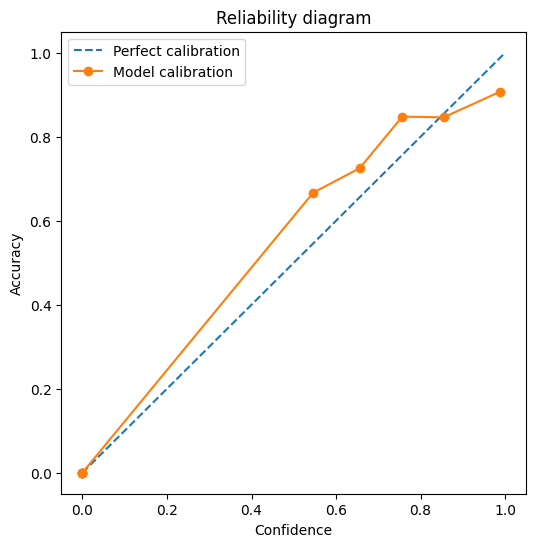

In [92]:
num_bins = 10

confidence = torch.where(pred_mean >= 0.5, pred_mean, 1 - pred_mean)
correct = (y_pred == Y_test_t).float()

bins = torch.linspace(0.0, 1.0, num_bins + 1)

bin_confidences = []
bin_accuracies = []
bin_counts = []

ece = 0.0

for i in range(num_bins):
    lower = bins[i]
    upper = bins[i + 1]

    if i == num_bins - 1:
        mask = (confidence >= lower) & (confidence <= upper)
    else:
        mask = (confidence >= lower) & (confidence < upper)

    count = mask.sum().item()

    if count > 0:
        avg_conf = confidence[mask].mean().item()
        avg_acc = correct[mask].mean().item()
    else:
        avg_conf = 0.0
        avg_acc = 0.0

    bin_confidences.append(avg_conf)
    bin_accuracies.append(avg_acc)
    bin_counts.append(count)

    ece += (count / len(confidence)) * abs(avg_acc - avg_conf)

print(f"Expected Calibration Error: {ece:.4f}")

plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
plt.plot(bin_confidences, bin_accuracies, marker="o", label="Model calibration")
plt.xlabel("Confidence")
plt.ylabel("Accuracy")
plt.title("Reliability diagram")
plt.legend()
plt.show()

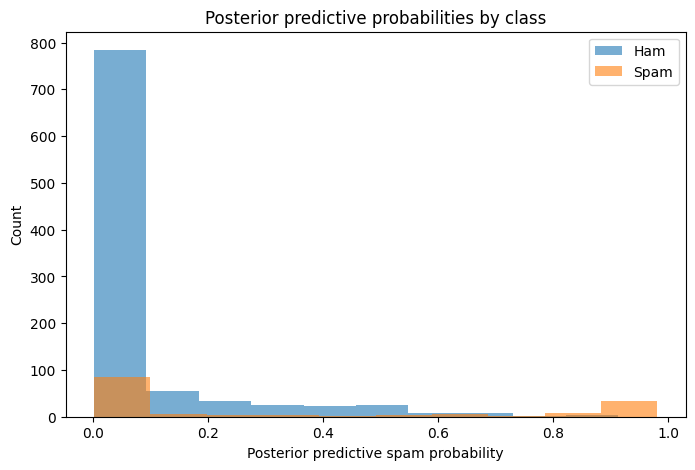

In [93]:
plt.figure(figsize=(8, 5))
plt.hist(pred_mean[Y_test_t == 0].numpy(), alpha=0.6, label="Ham")
plt.hist(pred_mean[Y_test_t == 1].numpy(), alpha=0.6, label="Spam")
plt.xlabel("Posterior predictive spam probability")
plt.ylabel("Count")
plt.title("Posterior predictive probabilities by class")
plt.legend()
plt.show()

In [94]:
# Separate predicted spam probabilities by true class
ham_probs = pred_mean[Y_test_t == 0]
spam_probs = pred_mean[Y_test_t == 1]

# Classification threshold
threshold = 0.5

ham_correct = (ham_probs < threshold).sum().item()
ham_total = len(ham_probs)

spam_correct = (spam_probs >= threshold).sum().item()
spam_total = len(spam_probs)

false_positives = (ham_probs >= threshold).sum().item()
false_negatives = (spam_probs < threshold).sum().item()


print("Posterior predictive probability summary")
print("----------------------------------------")
print(f"Ham examples: {ham_total}")
print(f"Spam examples: {spam_total}")
print()
print(f"Correctly classified ham: {ham_correct}/{ham_total} ({ham_correct / ham_total:.4f})")
print(f"Correctly classified spam: {spam_correct}/{spam_total} ({spam_correct / spam_total:.4f})")
print()
print(f"False positives, ham predicted as spam: {false_positives}")
print(f"False negatives, spam predicted as ham: {false_negatives}")
print()
print(f"Mean predicted spam probability for ham: {ham_probs.mean().item():.4f}")
print(f"Mean predicted spam probability for spam: {spam_probs.mean().item():.4f}")
print()
print(f"Median predicted spam probability for ham: {ham_probs.median().item():.4f}")
print(f"Median predicted spam probability for spam: {spam_probs.median().item():.4f}")
print()
print(f"Mean posterior uncertainty for ham: {pred_std[Y_test_t == 0].mean().item():.4f}")
print(f"Mean posterior uncertainty for spam: {pred_std[Y_test_t == 1].mean().item():.4f}")

Posterior predictive probability summary
----------------------------------------
Ham examples: 966
Spam examples: 149

Correctly classified ham: 933/966 (0.9658)
Correctly classified spam: 51/149 (0.3423)

False positives, ham predicted as spam: 33
False negatives, spam predicted as ham: 98

Mean predicted spam probability for ham: 0.0703
Mean predicted spam probability for spam: 0.3270

Median predicted spam probability for ham: 0.0054
Median predicted spam probability for spam: 0.0450

Mean posterior uncertainty for ham: 0.1118
Mean posterior uncertainty for spam: 0.1741


I selected Expected Calibration Error and calibration curves because this model is Bayesian and should therefore be evaluated not only by whether its classifications are correct, but also by whether its predicted probabilities are meaningful. Accuracy alone is insufficient, since a model can classify many examples correctly while still being overconfident or underconfident. Calibration evaluates whether predicted probabilities correspond to empirical correctness, making it a suitable evaluation method for a probabilistic model.

The implementation samples many weight vectors from the learned variational posterior distribution and computes posterior predictive probabilities for the holdout set. For each message, the mean posterior predictive probability is used as the final spam probability, while the standard deviation across posterior samples is interpreted as predictive uncertainty. I then compute the Expected Calibration Error and plot a reliability diagram. The reliability diagram groups predictions into confidence bins and compares the average confidence in each bin with the observed accuracy. A well-calibrated model should lie close to the diagonal reference line.

The calibration results show whether the learned variational posterior produces useful probabilistic predictions. If the calibration curve is close to the diagonal and the ECE is low, then the model’s predicted probabilities are relatively trustworthy. If the curve lies below the diagonal, the model is overconfident; if it lies above the diagonal, the model is underconfident. In my results, the Expected Calibration Error is approximately 0.078, suggesting that the model’s probabilities are reasonably informative, although not perfectly calibrated.

The posterior predictive histogram gives an additional view of the model’s behaviour. Most ham messages receive very low spam probabilities, so the model is confident when identifying non-spam messages. Spam messages receive higher spam probabilities on average, but the two distributions still overlap substantially. This means that some spam messages are assigned low spam probabilities and pass through as false negatives. The posterior uncertainty is also higher for spam than for ham, which suggests that spam examples are harder for the model and that the variational posterior captures some of this uncertainty.

## Appendix
The following threshold table is included only as supplementary context for interpreting the posterior predictive probabilities. The selected advanced evaluation remains Expected Calibration Error and the calibration curve.

In [ ]:
thresholds = torch.linspace(0.05, 0.95, 19)

print("Threshold | Accuracy | Spam recall | Ham recall | False positives | False negatives")
print("----------|----------|-------------|------------|-----------------|----------------")

for threshold in thresholds:
    y_pred_threshold = (pred_mean >= threshold).float()

    accuracy = (y_pred_threshold == Y_test_t).float().mean().item()

    ham_mask = Y_test_t == 0
    spam_mask = Y_test_t == 1

    ham_recall = (y_pred_threshold[ham_mask] == 0).float().mean().item()
    spam_recall = (y_pred_threshold[spam_mask] == 1).float().mean().item()

    false_positives = ((y_pred_threshold == 1) & (Y_test_t == 0)).sum().item()
    false_negatives = ((y_pred_threshold == 0) & (Y_test_t == 1)).sum().item()

    print(
        f"{threshold.item():.2f}      | "
        f"{accuracy:.4f}   | "
        f"{spam_recall:.4f}      | "
        f"{ham_recall:.4f}     | "
        f"{false_positives:15d} | "
        f"{false_negatives:15d}"
    )